In [80]:
import pandas as pd 

df = pd.read_csv("../../data/practice.csv")
df

,Age,Experience,EducationYears,WorkHours,ProjectsCompleted,SkillScore,PerformanceScore,Salary,PromotionLastYear,Attrition
0,25,2,16,40,3,70,75,3000.0,0.0,0
1,28,4,16,42,5,78,80,4200.0,1.0,0
2,35,10,18,45,8,88,90,7500.0,1.0,0
3,40,15,18,50,10,92,94,9000.0,1.0,0
4,23,1,14,38,2,65,70,NaN,0.0,1
5,30,6,16,44,6,82,85,5200.0,1.0,0
6,45,20,20,55,12,95,96,12000.0,1.0,0
7,38,12,18,48,9,89,91,NaN,1.0,0
8,26,3,16,40,4,74,76,3500.0,0.0,1
9,32,7,17,43,6,80,83,5500.0,1.0,0


In [36]:
df.columns

Index(['Age', 'Experience', 'EducationYears', 'WorkHours', 'ProjectsCompleted',
       'SkillScore', 'PerformanceScore', 'Salary', 'PromotionLastYear',
       'Attrition'],
      dtype='object')

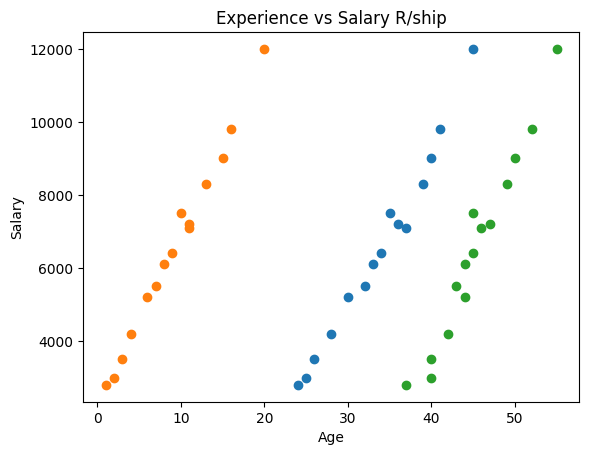

In [84]:
# using scatter plot ot identify whether to use linear or not ?
import matplotlib.pyplot as plt
completed_data = df.dropna()

plt.scatter(completed_data['Age'], completed_data['Salary'])
plt.scatter(completed_data['Experience'], completed_data['Salary'])
plt.scatter(completed_data['WorkHours'], completed_data['Salary'])
plt.xlabel('Age')
plt.ylabel('Salary')
plt.title("Experience vs Salary R/ship")
plt.show()


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                20 non-null     int64  
 1   Experience         20 non-null     int64  
 2   EducationYears     20 non-null     int64  
 3   WorkHours          20 non-null     int64  
 4   ProjectsCompleted  20 non-null     int64  
 5   SkillScore         20 non-null     int64  
 6   PerformanceScore   20 non-null     int64  
 7   Salary             17 non-null     float64
 8   PromotionLastYear  18 non-null     float64
 9   Attrition          20 non-null     int64  
dtypes: float64(2), int64(8)
memory usage: 1.7 KB


In [38]:
df.isnull().sum()

Age                  0
Experience           0
EducationYears       0
WorkHours            0
ProjectsCompleted    0
SkillScore           0
PerformanceScore     0
Salary               3
PromotionLastYear    2
Attrition            0
dtype: int64

In [39]:
from sklearn.linear_model import LinearRegression 

# step 1. lets classify/split  the data into 
completed_data =df[df['Salary'].notnull()]
incompleted_data = df[df['Salary'].isnull()]

#step 2. lets use the completed or df with out missing values 
# for training 
# 2.1 Independent variable{columns with out missing values }
x_train = completed_data[['Age', 'Experience', 'EducationYears', 'WorkHours', 'ProjectsCompleted',
       'SkillScore', 'PerformanceScore','Attrition']]
# 2.2 Dependent variable {columns we need to fill with the predicted data}
y_train = completed_data['Salary']

# step 3. train the model or biuld the model
model = LinearRegression()
model.fit(x_train , y_train)

# step 4. Predicting for the missing value and fill values 
df.loc[df['Salary'].isnull(),'Salary'] = model.predict(incompleted_data[['Age', 'Experience', 'EducationYears', 'WorkHours', 'ProjectsCompleted',
       'SkillScore', 'PerformanceScore','Attrition']])

# check the result and save back to csv 
df

,Age,Experience,EducationYears,WorkHours,ProjectsCompleted,SkillScore,PerformanceScore,Salary,PromotionLastYear,Attrition
0,25,2,16,40,3,70,75,3000.000000,0.0,0
1,28,4,16,42,5,78,80,4200.000000,1.0,0
2,35,10,18,45,8,88,90,7500.000000,1.0,0
3,40,15,18,50,10,92,94,9000.000000,1.0,0
4,23,1,14,38,2,65,70,2420.686231,0.0,1
5,30,6,16,44,6,82,85,5200.000000,1.0,0
6,45,20,20,55,12,95,96,12000.000000,1.0,0
7,38,12,18,48,9,89,91,7869.386642,1.0,0
8,26,3,16,40,4,74,76,3500.000000,0.0,1
9,32,7,17,43,6,80,83,5500.000000,1.0,0


In [40]:
print(df['Salary'].isnull().sum())

0


In [42]:
df.isnull().sum()


Age                  0
Experience           0
EducationYears       0
WorkHours            0
ProjectsCompleted    0
SkillScore           0
PerformanceScore     0
Salary               0
PromotionLastYear    2
Attrition            0
dtype: int64

#since promotion is binary value we can use logestic regression 

In [51]:
from sklearn.linear_model import LogisticRegression 
#step 1. split the data 

completed_data = df[df['PromotionLastYear'].notnull()]
incompleted_data = df[df['PromotionLastYear'].isnull()]

# step 2. train the model using the completed data 

x_train = completed_data[['Age', 'Experience', 'EducationYears', 'WorkHours', 'ProjectsCompleted',
       'SkillScore', 'PerformanceScore', 'Salary','Attrition']]
y_train = completed_data[['PromotionLastYear']]

# step 3. bliud the model 

model = LogisticRegression()
model.fit(x_train , y_train)

# step 4. predict and give it back 

if not incompleted_data.empty:
    df.loc[df['PromotionLastYear'].isnull(), 'PromotionLastYear'] = model.predict(incompleted_data[['Age', 'Experience', 'EducationYears', 'WorkHours', 'ProjectsCompleted',
       'SkillScore', 'PerformanceScore', 'Salary','Attrition']])


df

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,Age,Experience,EducationYears,WorkHours,ProjectsCompleted,SkillScore,PerformanceScore,Salary,PromotionLastYear,Attrition
0,25,2,16,40,3,70,75,3000.000000,0.0,0
1,28,4,16,42,5,78,80,4200.000000,1.0,0
2,35,10,18,45,8,88,90,7500.000000,1.0,0
3,40,15,18,50,10,92,94,9000.000000,1.0,0
4,23,1,14,38,2,65,70,2420.686231,0.0,1
5,30,6,16,44,6,82,85,5200.000000,1.0,0
6,45,20,20,55,12,95,96,12000.000000,1.0,0
7,38,12,18,48,9,89,91,7869.386642,1.0,0
8,26,3,16,40,4,74,76,3500.000000,0.0,1
9,32,7,17,43,6,80,83,5500.000000,1.0,0


In [52]:
df.isnull().sum()

Age                  0
Experience           0
EducationYears       0
WorkHours            0
ProjectsCompleted    0
SkillScore           0
PerformanceScore     0
Salary               0
PromotionLastYear    0
Attrition            0
dtype: int64

In [ ]:
df['PromotionLastYear']

This is how the model based imputation is done using the logistic and linear imputation 

In [76]:
import pandas as pd 
df = pd.read_csv('../../data/practice2.csv')

In [77]:
df

,Age,Experience,SkillScore,Salary
0,22,1.0,60,2500.0
1,23,1.5,62,2700.0
2,24,2.0,65,3000.0
3,25,2.5,67,NaN
4,26,3.0,70,3600.0
5,27,3.5,72,4000.0
6,28,4.0,74,NaN
7,29,4.5,76,4800.0
8,30,5.0,78,5400.0
9,31,5.5,80,NaN


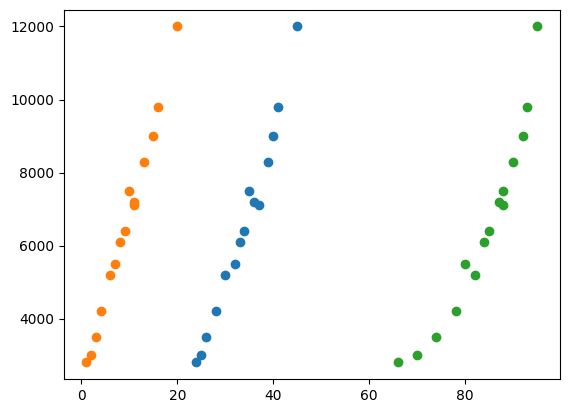

In [88]:
# lets identify what should we use 
# 1. linear  or polynomial Regression 

import matplotlib.pyplot as plt

completed_data = df.dropna()
plt.scatter(completed_data['Age'],completed_data['Salary'] )
plt.scatter(completed_data['Experience'],completed_data['Salary'] )
plt.scatter(completed_data['SkillScore'],completed_data['Salary'] )
plt.show()

In [61]:
df.isnull().sum()
df.columns

Index(['Age', 'Experience', 'SkillScore', 'Salary'], dtype='object')

In [78]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression 

completed_data = df[df['Salary'].notnull()]
incompleted_data = df[df['Salary'].isnull()]

x_train = completed_data[['Age', 'Experience', 'SkillScore']]
y_train = completed_data[['Salary']]
x_test = incompleted_data[['Age', 'Experience', 'SkillScore']]

ploy = PolynomialFeatures(degree= 2)
x_poly = ploy.fit_transform(x_train)
if not incompleted_data.empty:
    x_poly_tran = ploy.fit_transform(x_test)

model = LinearRegression()
model.fit(x_poly, y_train)

df.loc[df['Salary'].isnull(), 'Salary'] = model.predict(x_poly_tran)





In [79]:
df

,Age,Experience,SkillScore,Salary
0,22,1.0,60,2500.000000
1,23,1.5,62,2700.000000
2,24,2.0,65,3000.000000
3,25,2.5,67,3200.859134
4,26,3.0,70,3600.000000
5,27,3.5,72,4000.000000
6,28,4.0,74,4381.497196
7,29,4.5,76,4800.000000
8,30,5.0,78,5400.000000
9,31,5.5,80,5909.806610
